In [8]:
import sys
import os

# Add parent and grandparent directories to sys.path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

import numpy as np
from scipy import linalg
from scipy.linalg import expm

import matplotlib.pyplot as plt

# import KrylovComplexity class
from src.krylov_complexity import KrylovComplexity

# Functions for calculation

## Hamiltonians

In [9]:
# Hamiltonian for 2-qubit XX+YY model
def xx_yy_hamiltonian(J=1.0):
    """
    Two-qubit XX+YY Hamiltonian

    Parameters
    ----------
    - J: Coupling strength

    Returns 
    -------
    - H: (4x4) XX+YY Hamiltonian matrix 
    """
    sx = np.array([[0, 1], [1, 0]])
    sy = np.array([[0, -1j], [1j, 0]])
    I = np.eye(2)

    XX = np.kron(sx, sx)
    YY = np.kron(sy, sy)

    return J * (XX + YY)


In [10]:
def xx_yy_chain_hamiltonian(n_qubits, J=1.0, periodic=False):
    """
    N-qubit XX+YY chain Hamiltonian

    Parameters
    ----------
    - n_qubits: Number of qubits in the chain
    - J: Coupling strength
    - periodic: Whether to use periodic boundary conditions

    Returns
    -------
    - H: (2^n × 2^n) Hamiltonian matrix

    System sizes and computational complexity
    -----------------------------------------
    - 2 qubits: 4×4 matrices, ~KB memory
    - 3 qubits: 8×8 matrices, ~KB memory
    - 4 qubits: 16×16 matrices, ~KB memory
    - 5 qubits: 32×32 matrices, ~KB memory
    - 6 qubits: 64×64 matrices, ~MB memory
    - 7 qubits: 128×128 matrices, ~MB memory
    - 8 qubits: 256×256 matrices, ~MB memory
    - 10 qubits: 1024×1024 matrices, ~GB memory (limit for dense matrices)
    """
    if n_qubits < 2:
        raise ValueError("Need at least 2 qubits for XX+YY interaction")

    # Pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    I = np.eye(2, dtype=complex)

    # Initialize Hamiltonian
    dim = 2 ** n_qubits
    H = np.zeros((dim, dim), dtype=complex)

    # Add nearest-neighbor XX+YY interactions
    for i in range(n_qubits - 1):
        # Create operator list for tensor product
        ops_x = [I] * n_qubits
        ops_y = [I] * n_qubits

        ops_x[i] = sx
        ops_x[i + 1] = sx

        ops_y[i] = sy
        ops_y[i + 1] = sy

        # Compute tensor products
        XX_term = ops_x[0]
        YY_term = ops_y[0]

        for j in range(1, n_qubits):
            XX_term = np.kron(XX_term, ops_x[j])
            YY_term = np.kron(YY_term, ops_y[j])

        H += J * (XX_term + YY_term)

    # Add periodic boundary condition if requested
    if periodic and n_qubits > 2:
        ops_x = [I] * n_qubits
        ops_y = [I] * n_qubits

        ops_x[0] = sx
        ops_x[-1] = sx

        ops_y[0] = sy
        ops_y[-1] = sy

        XX_term = ops_x[0]
        YY_term = ops_y[0]

        for j in range(1, n_qubits):
            XX_term = np.kron(XX_term, ops_x[j])
            YY_term = np.kron(YY_term, ops_y[j])

        H += J * (XX_term + YY_term)

    return H

## Initial operator

In [11]:
def create_initial_operator(n_qubits, op_type='single_z', position=0):
    """
    Create initial operators for different system sizes

    Parameters
    ----------
    - n_qubits: System size
    - op_type: Type of initial operator
        - 'single_z': σᶻ at position, I elsewhere
        - 'random_pauli': Random Pauli operator
        - 'local_sum': Sum of nearby Pauli operators
    - position: Position for single-site operators

    Returns
    -------
    - operator: (2^n × 2^n) initial operator matrix
    """
    if position >= n_qubits:
        raise ValueError(f"Position {position} >= n_qubits {n_qubits}")

    # Pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    I = np.eye(2, dtype=complex)

    if op_type == 'single_z':
        # Single σᶻ at specified position
        ops = [I] * n_qubits
        ops[position] = sz

        operator = ops[0]
        for i in range(1, n_qubits):
            operator = np.kron(operator, ops[i])

    elif op_type == 'random_pauli':
        # Random Pauli string
        paulis = [I, sx, sy, sz]
        ops = [np.random.choice(paulis) for _ in range(n_qubits)]

        operator = ops[0]
        for i in range(1, n_qubits):
            operator = np.kron(operator, ops[i])

    elif op_type == 'local_sum':
        # Sum of nearby operators (more spread out)
        operator = np.zeros((2 ** n_qubits, 2 ** n_qubits), dtype=complex)

        for pos in range(min(3, n_qubits)):  # Up to 3 sites
            ops = [I] * n_qubits
            ops[pos] = sz

            local_op = ops[0]
            for i in range(1, n_qubits):
                local_op = np.kron(local_op, ops[i])

            operator += local_op

    else:
        raise ValueError(f"Unknown operator type: {op_type}")

    # Normalize
    norm_val = np.sqrt(np.real(np.trace(operator.conj().T @ operator) / (2 ** n_qubits)))
    if norm_val > 1e-12:
        operator = operator / norm_val

    return operator

# Functions for visualization and analysis

## Analyzing system scaling 

In [42]:
def analyze_system_scaling(
        dt = 0.2,
        t_max = 15,
        system_sizes = [2, 3, 4, 5, 6, 8], # Beyond 6-7 qubits becomes computationally expensive
        ):
    """
    Analyze Krylov complexity for different system sizes.
    Shows computational limits and scaling behavior. 

    Parameters
    ----------
    - dt: time interval for each time step
    - t_max: maximum time steps to run for
    - system_sizes: list of sizes of systems (number of qubits) for each trial

    Returns
    -------
    - results_by_size: dictionary containing results for each system size
    """
    print("System Size Analysis for XX+YY Krylov Complexity")
    print("=" * 60)

    results_by_size = {}

    for n_qubits in system_sizes:
        print(f"\nAnalyzing {n_qubits}-qubit system...")

        # Memory requirements
        dim = 2 ** n_qubits
        memory_mb = (dim ** 2 * 16) / (1024 ** 2)  # Complex128 = 16 bytes
        print(f"  Hilbert space dimension: {dim}")
        print(f"  Operator space dimension: {dim ** 2}")
        print(f"  Memory per operator: {memory_mb:.2f} MB")

        if memory_mb > 1000:  # Skip if too large
            print(f"  Skipping - too large for demonstration")
            continue

        try:
            # Create Hamiltonian and initial operator
            H = xx_yy_chain_hamiltonian(n_qubits, J=1.0)
            initial_op = create_initial_operator(n_qubits, 'single_z', position=0)

            # Create an instance of KrylovComplexity class
            krylov_complexity = KrylovComplexity(hamiltonian = H, 
                                            dt = dt, 
                                            O0 = initial_op)
            # Run analysis
            results = krylov_complexity.analyze(t_max=t_max)
            results_by_size[n_qubits] = results

            print(f"  Max complexity: {max(results['complexity']):.3f}")
            print(f"  Krylov dimension: {len(results['krylov_operators'])}")
            print(f"  Final b coefficient: {results['lanczos_b'][-1]:.3f}")

        except MemoryError:
            print(f"  Memory error - system too large")
            break
        except Exception as e:
            print(f"  Error: {e}")

    # Plot scaling comparison
    if len(results_by_size) > 1:
        plt.figure(figsize=(15, 5))

        # Plot 1: Complexity curves
        plt.subplot(1, 3, 1)
        colors = plt.cm.viridis(np.linspace(0, 1, len(results_by_size)))

        for i, (n_qubits, results) in enumerate(results_by_size.items()):
            times = np.arange(len(results['complexity'])) * dt
            plt.plot(times, results['complexity'], color=colors[i],
                     linewidth=2, label=f'{n_qubits} qubits')

        plt.xlabel('Time')
        plt.ylabel('Krylov Complexity')
        plt.xlim(min(times),max(times))
        plt.title('Complexity vs System Size')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 2: Max complexity scaling
        plt.subplot(1, 3, 2)
        sizes = list(results_by_size.keys())
        max_complexities = [max(results_by_size[n]['complexity']) for n in sizes]

        plt.plot(sizes, max_complexities, 'ro-', linewidth=2, markersize=8)
        plt.xlabel('Number of Qubits')
        plt.ylabel('Maximum Complexity')
        plt.title('Complexity Scaling')
        plt.grid(True, alpha=0.3)

        # Plot 3: Krylov dimension scaling
        plt.subplot(1, 3, 3)
        krylov_dims = [len(results_by_size[n]['krylov_operators']) for n in sizes]

        plt.plot(sizes, krylov_dims, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Number of Qubits')
        plt.ylabel('Krylov Subspace Dimension')
        plt.title('Krylov Dimension Scaling')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return results_by_size

## Visualization

In [13]:
def visualize_krylov_analysis(results, dt, save_plots=False):
    """
    Comprehensive visualization of Krylov complexity analysis

    Parameters
    ----------
    - results: results of KrylovComplexity analysis
    - dt: time interval for each time step 
    - save_plots: whether or not to save the plots as .png file
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Krylov Complexity Analysis for XX+YY Quantum Circuit', fontsize=16)

    # Plot 1: Krylov Complexity vs Time
    times = np.arange(len(results['complexity'])) * dt
    axes[0, 0].plot(times, results['complexity'], 'b-', linewidth=2, marker='o', markersize=4)
    axes[0, 0].set_xlabel('Time (ℏ/J)')
    axes[0, 0].set_ylabel('Krylov Complexity K(t)')
    axes[0, 0].set_title('Complexity Growth')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Lanczos Coefficients
    n_vals = np.arange(len(results['lanczos_b']))
    axes[0, 1].plot(n_vals, results['lanczos_b'], 'r-', linewidth=2, marker='s',
                    markersize=4, label='$b_n$ (off-diagonal)')
    if len(results['lanczos_a']) > 0:
        axes[0, 1].plot(np.arange(len(results['lanczos_a'])), results['lanczos_a'],
                        'g-', linewidth=2, marker='^', markersize=4, label='$a_n$ (diagonal)')
    axes[0, 1].set_xlabel('Krylov Index n')
    axes[0, 1].set_ylabel('Coefficient Value')
    axes[0, 1].set_title('Lanczos Coefficients')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Complexity Growth Rate
    if len(results['complexity']) > 1:
        growth_rate = np.diff(results['complexity']) / dt
        axes[0, 2].plot(times[1:], growth_rate, 'purple', linewidth=2, marker='o', markersize=3)
        axes[0, 2].set_xlabel('Time (ℏ/J)')
        axes[0, 2].set_ylabel('dK/dt')
        axes[0, 2].set_title('Complexity Growth Rate')
        axes[0, 2].grid(True, alpha=0.3)

    # Plot 4: Expansion Coefficients Heatmap
    if 'expansion_coefficients' in results and len(results['expansion_coefficients']) > 0:
        # Create coefficient matrix
        max_n = min(20, len(results['expansion_coefficients'][0]))  # Limit for visualization
        coeff_matrix = np.zeros((len(results['expansion_coefficients']), max_n))

        for t, coeffs in enumerate(results['expansion_coefficients']):
            for n in range(min(max_n, len(coeffs))):
                coeff_matrix[t, n] = abs(coeffs[n]) ** 2

        im = axes[1, 0].imshow(coeff_matrix.T, aspect='auto', origin='lower', cmap='viridis')
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('Krylov Index n')
        axes[1, 0].set_title('|Expansion Coefficients|²')
        plt.colorbar(im, ax=axes[1, 0])

    # Plot 5: Autocorrelation Function (if available)
    if 'autocorrelation' in results:
        axes[1, 1].plot(times, np.real(results['autocorrelation']), 'b-',
                        linewidth=2, label='Real part')
        axes[1, 1].plot(times, np.imag(results['autocorrelation']), 'r--',
                        linewidth=2, label='Imaginary part')
        axes[1, 1].set_xlabel('Time (ℏ/J)')
        axes[1, 1].set_ylabel('⟨O₀|O(t)⟩')
        axes[1, 1].set_title('Autocorrelation Function')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Convergence Analysis
    if len(results['lanczos_b']) > 5:
        # Check convergence to maximally ergodic regime
        b_convergence = np.abs(np.array(results['lanczos_b']) - 1.0)
        axes[1, 2].semilogy(n_vals, b_convergence, 'orange', linewidth=2, marker='d', markersize=4)
        axes[1, 2].set_xlabel('Krylov Index n')
        axes[1, 2].set_ylabel('|$b_n$ - 1|')
        axes[1, 2].set_title('Convergence to Maximally Ergodic')
        axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_plots:
        plt.savefig('krylov_analysis.png', dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
def compare_trotter_steps(hamiltonian, dt_values, t_max, initial_op):
    """
    Visualize comparison of Krylov complexity for different Trotter step sizes

    Parameters
    ----------
    - hamiltonian: the hamiltonian with which to do the analysis 
    - dt_values: list of time interval values
    - t_max: int number of time steps to run analysis for
    - initial_op: initial operator
    """
    plt.figure(figsize=(15, 10))

    colors = plt.cm.viridis(np.linspace(0, 1, len(dt_values)))

    # Plot 1: Complexity vs Time for different dt
    plt.subplot(2, 3, 1)
    for i, dt in enumerate(dt_values):
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        results = krylov.analyze(t_max=t_max)
        times = np.arange(len(results['complexity'])) * dt
        plt.plot(times, results['complexity'], color=colors[i],
                 linewidth=2, label=f'Δt = {dt:.3f}')

    plt.xlabel('Time (ℏ/J)')
    plt.ylabel('Krylov Complexity K(t)')
    plt.title('Complexity vs Trotter Step Size')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Lanczos b coefficients
    plt.subplot(2, 3, 2)
    for i, dt in enumerate(dt_values):
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        results = krylov.analyze(t_max=t_max)

        n_vals = np.arange(len(results['lanczos_b']))
        plt.plot(n_vals, results['lanczos_b'], color=colors[i],
                 linewidth=2, marker='o', markersize=3, label=f'Δt = {dt:.3f}')

    plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Maximally Ergodic')
    plt.xlabel('Krylov Index n')
    plt.ylabel('$b_n$ Coefficient')
    plt.title('Lanczos Coefficients vs Δt')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Growth rate analysis
    plt.subplot(2, 3, 3)
    growth_rates = []
    for dt in dt_values:
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        results = krylov.analyze(t_max=min(20, t_max))

        if len(results['complexity']) > 10:
            # Linear fit to extract growth rate
            times = np.arange(len(results['complexity'])) * dt
            early_times = times[5:15]  # Middle region
            early_complexity = results['complexity'][5:15]
            if len(early_complexity) > 0:
                growth_rate = np.polyfit(early_times, early_complexity, 1)[0]
                growth_rates.append(growth_rate)
            else:
                growth_rates.append(0)
        else:
            growth_rates.append(0)

    plt.plot(dt_values, growth_rates, 'ro-', linewidth=2, markersize=6)
    plt.xlabel('Trotter Step Δt')
    plt.ylabel('Linear Growth Rate')
    plt.title('Complexity Growth Rate vs Δt')
    plt.grid(True, alpha=0.3)

    # Plot 4: Phase diagram
    plt.subplot(2, 3, 4)
    convergence_times = []
    max_complexity = []

    for dt in dt_values:
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        results = krylov.analyze(t_max=min(20, t_max))

        # Find when b_n approaches 1 (convergence time)
        b_coeffs = np.array(results['lanczos_b'])
        if len(b_coeffs) > 0:
            convergence_idx = np.where(np.abs(b_coeffs - 1.0) < 0.1)[0]
            if len(convergence_idx) > 0:
                convergence_times.append(convergence_idx[0])
            else:
                convergence_times.append(len(b_coeffs))
            max_complexity.append(max(results['complexity']))
        else:
            convergence_times.append(0)
            max_complexity.append(0)

    plt.scatter(dt_values, convergence_times, c=max_complexity, cmap='plasma', s=100)
    plt.colorbar(label='Max Complexity')
    plt.xlabel('Trotter Step Δt')
    plt.ylabel('Convergence Time (Krylov steps)')
    plt.title('Convergence Phase Diagram')
    plt.grid(True, alpha=0.3)

    # Plot 5: Autocorrelation comparison
    plt.subplot(2, 3, 5)
    for i, dt in enumerate(dt_values):
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        autocorr = krylov.autocorrelation(t_max=min(30, t_max))
        
        times = np.arange(len(autocorr)) * dt
        plt.plot(times, np.abs(autocorr), color=colors[i],
                 linewidth=2, label=f'Δt = {dt:.3f}')

    plt.xlabel('Time (ℏ/J)')
    plt.ylabel('|⟨O₀|O(t)⟩|')
    plt.title('Autocorrelation Decay')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    # Plot 6: Critical transition analysis
    plt.subplot(2, 3, 6)
    dt_critical = np.pi / 8  # Critical value from paper for XX model
    plt.axvline(x=dt_critical, color='red', linestyle='--', linewidth=2,
                label=f'Critical Δt = π/8 ≈ {dt_critical:.3f}')

    ergodic_measure = []
    for dt in dt_values:
        # Create an instance of KrylovComplexity class
        krylov = KrylovComplexity(hamiltonian = hamiltonian, 
                                        dt = dt, 
                                        O0 = initial_op)
        # Run analysis
        results = krylov.analyze(t_max=min(15, t_max))

        # Measure how close b_n gets to 1
        if len(results['lanczos_b']) > 5:
            ergodic_measure.append(np.mean(results['lanczos_b'][-5:]))
        else:
            ergodic_measure.append(0)

    plt.plot(dt_values, ergodic_measure, 'bo-', linewidth=2, markersize=6)
    plt.xlabel('Trotter Step Δt')
    plt.ylabel('Average $b_n$ (last 5 values)')
    plt.title('Ergodic Transition')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Analysis examples

## Run analysis for 2-qubit XX+YY model

In [50]:
# Run analysis for 2-qubit XX+YY model
H = xx_yy_hamiltonian()
sz = np.array([[1, 0], [0, -1]])
initial_operator = np.kron(sz, np.eye(2))  # σᶻ ⊗ I

# create an instance of KrylovComplexity class for our 2-qubit XX+YY model example
t_max = 50
dt = 0.1
xx_yy_krylov = KrylovComplexity(hamiltonian = H, 
                                dt = dt, 
                                O0 = initial_operator)

# obtain analysis results
results = xx_yy_krylov.analyze(t_max=t_max)

Krylov analysis results dict keys: dict_keys(['complexity', 'krylov_operators', 'lanczos_a', 'lanczos_b', 'expansion_coefficients'])


(0.0, 5.0)

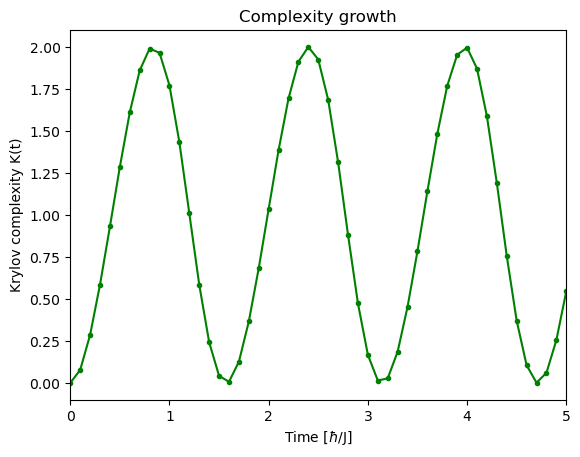

In [51]:
# see keys in "results" dictionary
print(f'Krylov analysis results dict keys: {results.keys()}')

# plot, for example, Krylov complexity
t_range = np.arange(t_max+1) * dt
plt.plot(t_range, results['complexity'], 
        color='green',marker='o',ms=3)
plt.xlabel(r'Time [$\hbar$/J]')
plt.ylabel('Krylov complexity K(t)')
plt.title('Complexity growth')
plt.xlim(min(t_range),max(t_range))

# to visualize the complete Krylov analysis results, instead of just one of the 
# results, use visualize_krylov_analysis() 

## Analyze system scaling

This shouldn't take very long (O(seconds)) up to 6-7 qubits. Beyond 6-7 qubits, it may take up to 10 minutes.

System Size Analysis for XX+YY Krylov Complexity

Analyzing 2-qubit system...
  Hilbert space dimension: 4
  Operator space dimension: 16
  Memory per operator: 0.00 MB
  Max complexity: 1.997
  Krylov dimension: 3
  Final b coefficient: 0.000

Analyzing 3-qubit system...
  Hilbert space dimension: 8
  Operator space dimension: 64
  Memory per operator: 0.00 MB
  Max complexity: 3.982
  Krylov dimension: 5
  Final b coefficient: 0.000

Analyzing 4-qubit system...
  Hilbert space dimension: 16
  Operator space dimension: 256
  Memory per operator: 0.00 MB
  Max complexity: 5.888
  Krylov dimension: 9
  Final b coefficient: 0.000

Analyzing 5-qubit system...
  Hilbert space dimension: 32
  Operator space dimension: 1024
  Memory per operator: 0.02 MB
  Max complexity: 10.315
  Krylov dimension: 31
  Final b coefficient: 0.959

Analyzing 6-qubit system...
  Hilbert space dimension: 64
  Operator space dimension: 4096
  Memory per operator: 0.06 MB
  Max complexity: 9.984
  Krylov dimensio

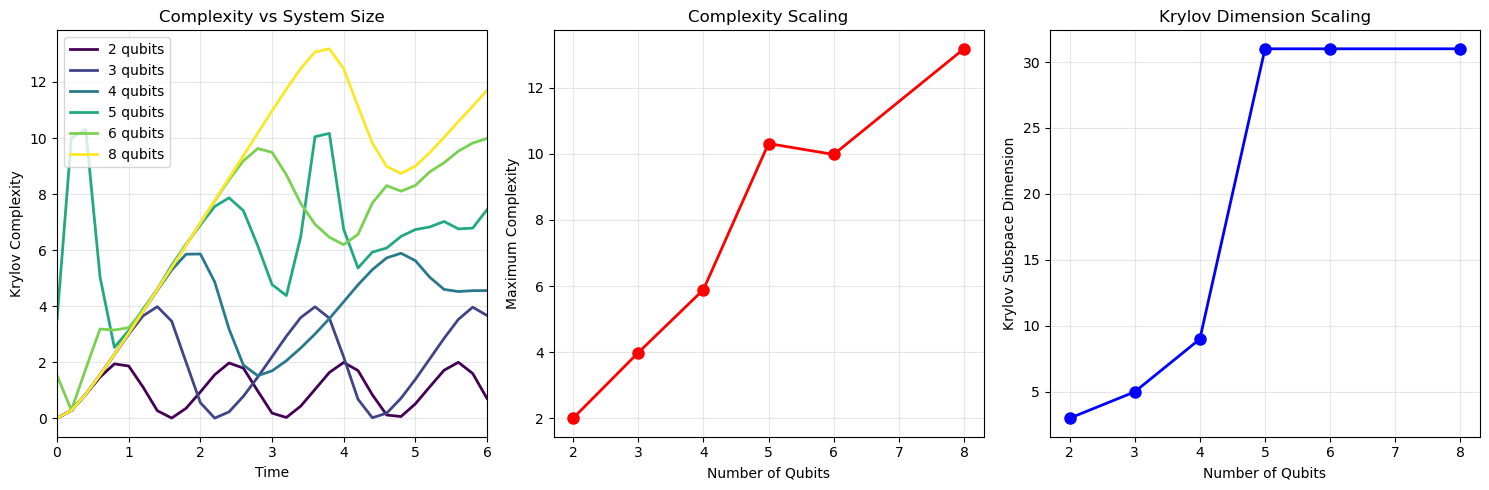

''

In [47]:
results_by_sys_size = analyze_system_scaling(
                                dt = 0.2,
                                t_max = 30,
                                system_sizes = [2, 3, 4, 5, 6, 8], # Beyond 6-7 qubits becomes computationally expensive
                            )
''

## Analysis showing Trotter transition for XX+YY model

In [56]:
def analyze_xx_yy_transitions():
    """
    Complete analysis of XX+YY model showing Trotter transitions
    """
    # Parameters
    J = 1.0
    dt_values = np.linspace(0.05, 0.5, 10)
    t_max = 30

    # Create XX+YY Hamiltonian
    H = xx_yy_hamiltonian(J)

    # Initial operator (single-site Pauli-Z)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    initial_operator = np.kron(sz, np.eye(2))

    print("Analyzing XX+YY Quantum Circuit Krylov Complexity...")
    print(f"Hamiltonian: XX + YY with J = {J}")
    print(f"Initial operator: σᶻ ⊗ I")
    print(f"Trotter steps: {dt_values}")
    print(f"Max time: {t_max}")
    print("=" * 50)

    # Single analysis for detailed view
    dt_example = 0.2
    print(f"\nDetailed analysis for Δt = {dt_example}")
    
    # Create an instance of KrylovComplexity class
    krylov_complexity = KrylovComplexity(hamiltonian = H, 
                                    dt = dt_example, 
                                    O0 = initial_operator)
    # Run analysis
    results = krylov_complexity.analyze(t_max=t_max)

    print(f"Max Krylov complexity: {max(results['complexity']):.3f}")
    print(f"Number of Krylov operators: {len(results['krylov_operators'])}")
    print(f"Final b coefficient: {results['lanczos_b'][-1]:.3f}")

    # Visualize single case
    visualize_krylov_analysis(results, dt_example)

    # Comparative analysis
    print("\nComparative analysis across Trotter steps...")
    compare_trotter_steps(H, dt_values, t_max,initial_operator)

    return results

Analyzing XX+YY Quantum Circuit Krylov Complexity...
Hamiltonian: XX + YY with J = 1.0
Initial operator: σᶻ ⊗ I
Trotter steps: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
Max time: 30

Detailed analysis for Δt = 0.2
Max Krylov complexity: 1.997
Number of Krylov operators: 3
Final b coefficient: 0.000


/opt/miniconda3/envs/QuNet/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/QuNet/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


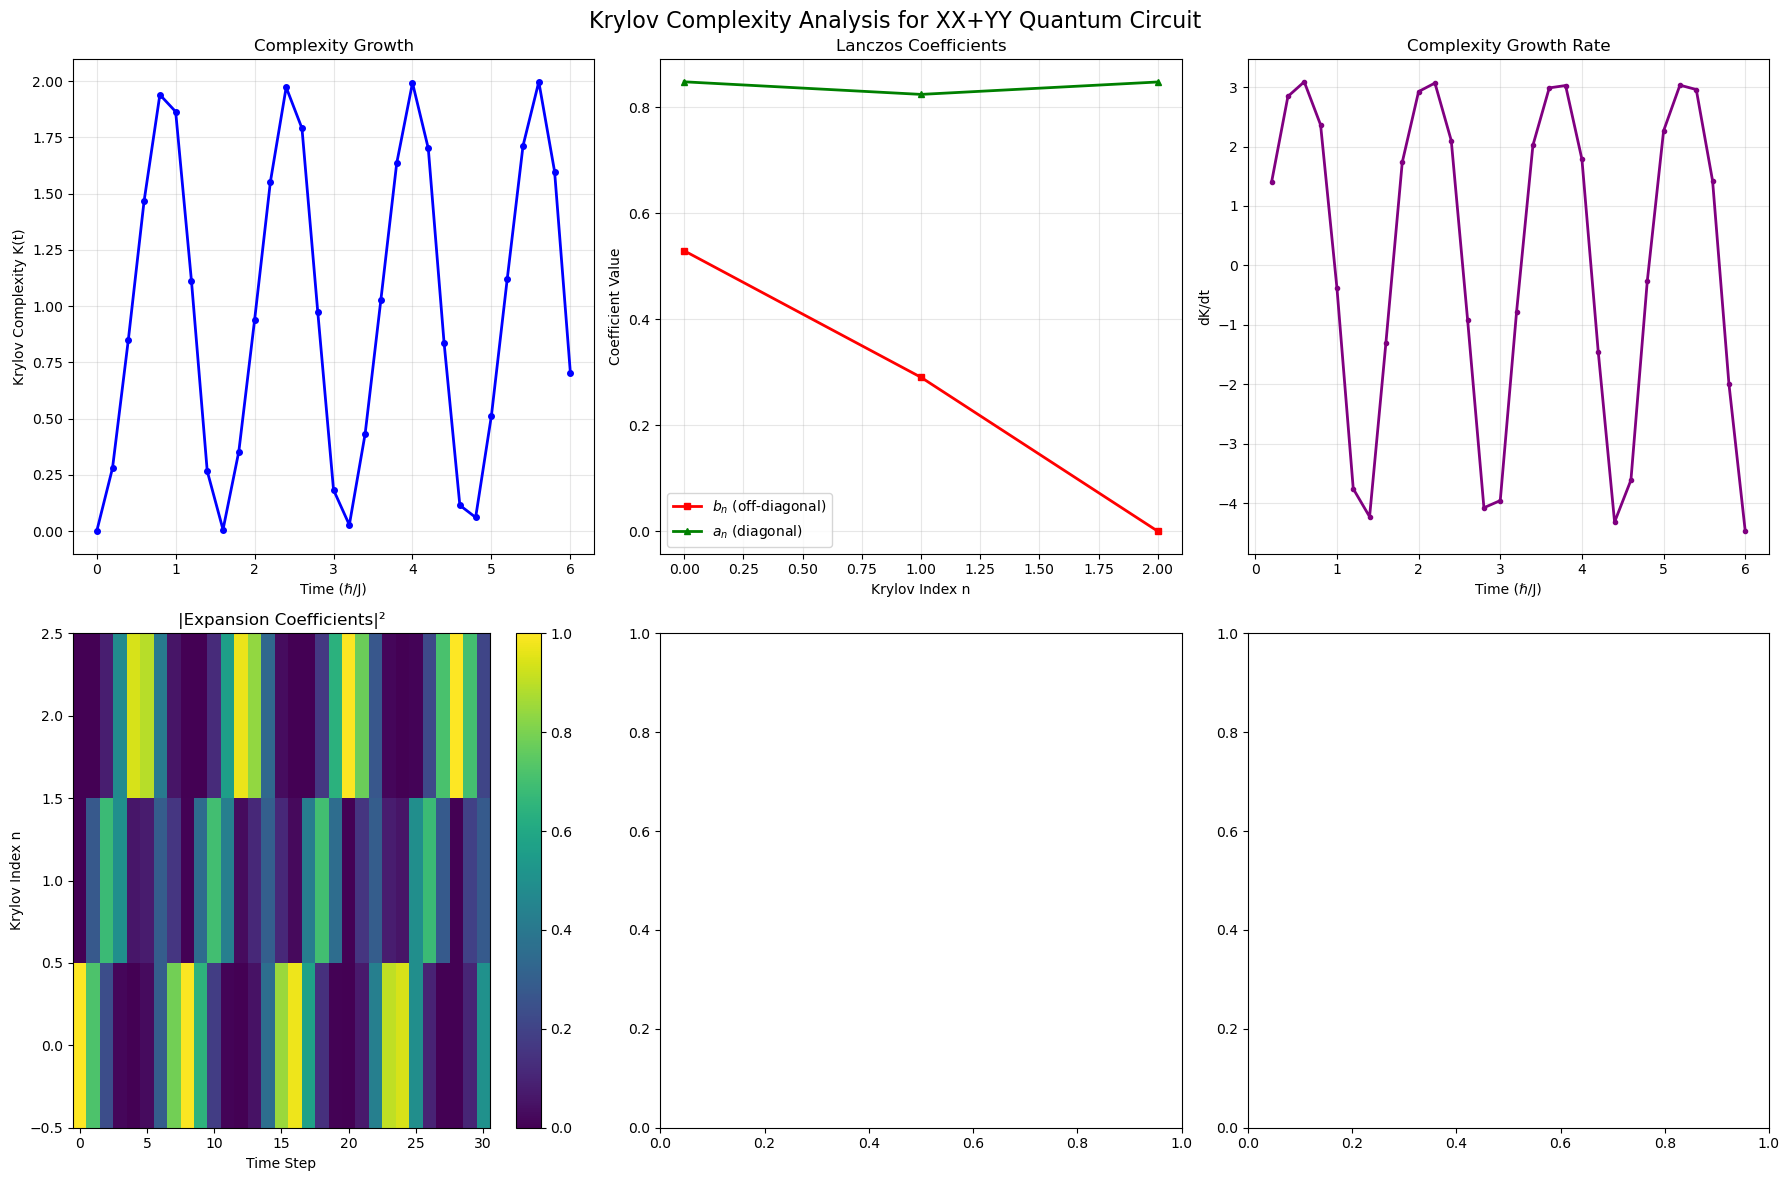


Comparative analysis across Trotter steps...


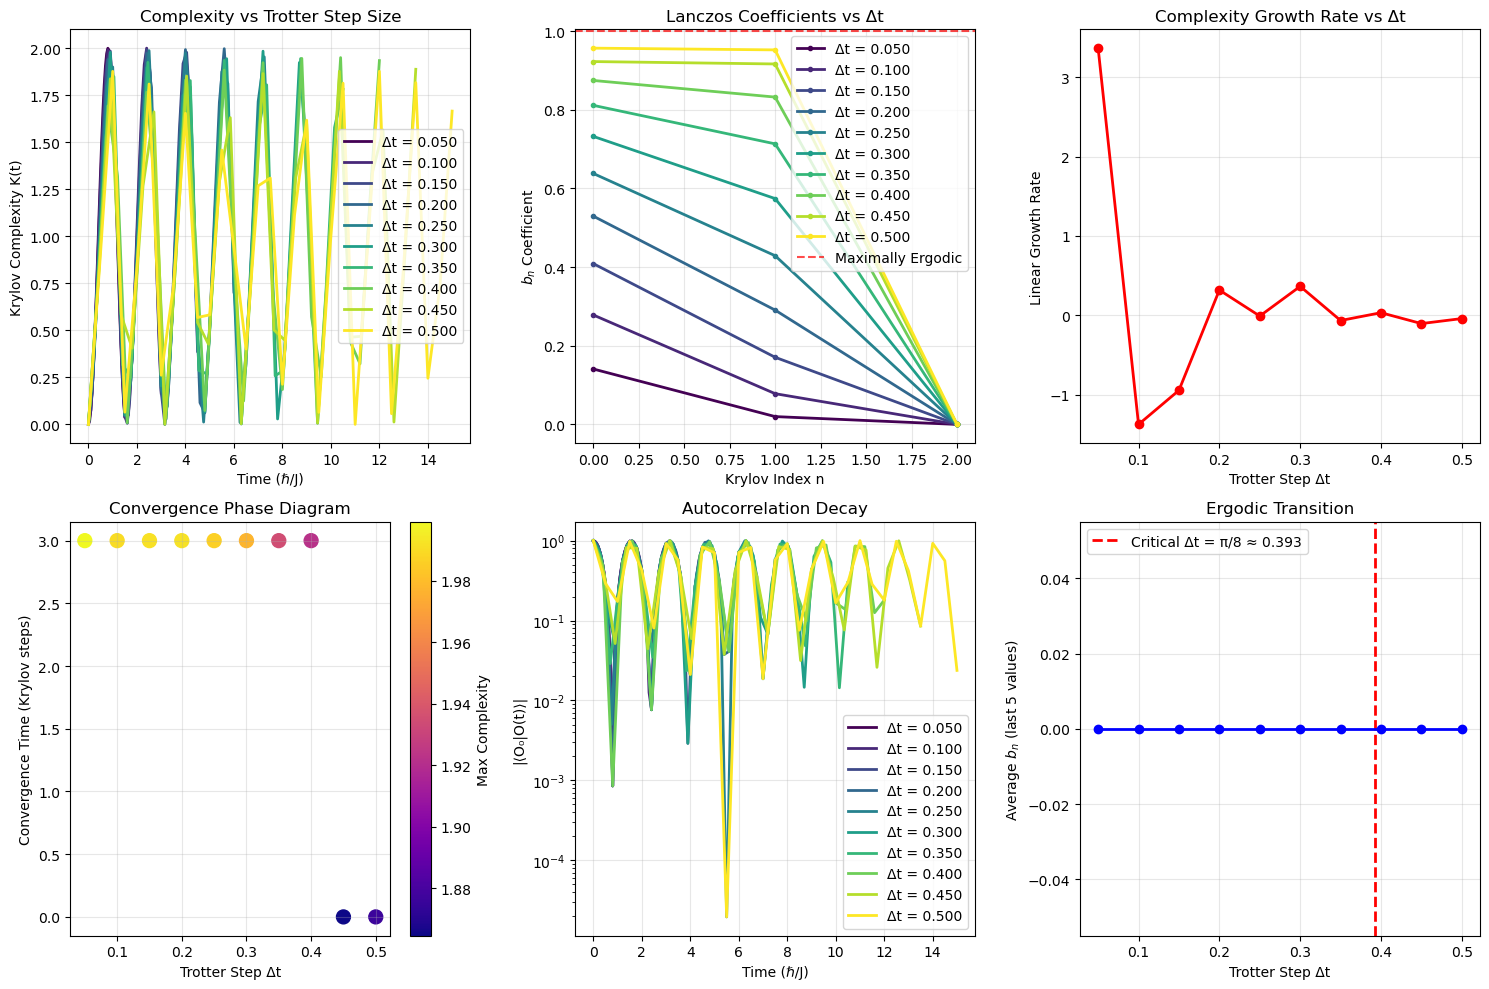

In [57]:
# Run to see what happens for XX YY ham
# Run complete analysis
results = analyze_xx_yy_transitions()

## Additional analysis for paper reproduction

In [21]:
# Additional analysis for paper reproduction
print("\nReproducing key results from the paper...")

# Test critical transition
dt_critical = np.pi / 8
H = xx_yy_hamiltonian()
sz = np.array([[1, 0], [0, -1]], dtype=complex)
initial_op = np.kron(sz, np.eye(2))
t_max = 20

# Create an instance of KrylovComplexity class
krylov_critical = KrylovComplexity(hamiltonian = H, 
                                dt = dt_critical, 
                                O0 = initial_op)
# Run analysis
results_critical = krylov_critical.analyze(t_max=t_max)

print(f"At critical Δt = π/8: max complexity = {max(results_critical['complexity']):.3f}")


# Test dual-unitary point
dt_dual = np.pi / 4
# Create an instance of KrylovComplexity class
krylov_dual = KrylovComplexity(hamiltonian = H, 
                                dt = dt_dual, 
                                O0 = initial_op)
# Run analysis
results_dual = krylov_dual.analyze(t_max=t_max)

print(f"At dual-unitary Δt = π/4: max complexity = {max(results_dual['complexity']):.3f}")


Reproducing key results from the paper...
At critical Δt = π/8: max complexity = 1.667
At dual-unitary Δt = π/4: max complexity = 1.000
